# Tournament analysis (260715): which models win in competition

Analyses the selfless-model tournament in `~/Unity/Octagon/simulations/tournaments/260715` (see [[octagon-tournament]] memory). 8 models, every ordered pair with mirrors plus self-matchups = **64 matchups**. Folder `260715_00A__vs__260715_00B` means model A drives agent 0 (P1), model B drives agent 1 (P2). Each trial is winner-take-all: the winner scores **1.0** (reached High) or **0.4** (reached Low), the loser 0.

**Goal:** which models are most successful in competition, using **player score over time** (accumulated player score) as the metric each agent is trying to maximise. Then whether the *interaction* of models (a specific pairing) matters beyond each model's general strength.

**This notebook covers**
1. **Run validation** — are the matchups complete and fair (self-matchups near 50%, mirror-consistent)? 
2. **Per-run results + head-to-head matrices** — the outcome of each matchup; raw score and win-rate matrices for reference.
3. **Overall ranking** — mean score per trial, total accumulated score, win rate, and a Bradley-Terry strength, per model.
4. **Pair interaction** — how much each head-to-head deviates from what the models' overall strengths predict (Bradley-Terry residual), plus a non-transitivity check for rock-paper-scissors loops.

Situational breakdowns (per wall separation) and behavioural strategy characterisation are left to a separate notebook.

> **Data note.** Run after the tournament finishes (every matchup has `DONE.txt`). The validation cell will flag any incomplete or unfair matchups.

> **Build note.** The tournament was run with `build_260724_01_tournament`, which has the no-movement penalty-break **absent** (every step penalised) — this does *not* match the training build (`260715_01_social`, break present). It does **not** affect this analysis: at inference the policy is fixed, so the step penalty changes only the logged **reward**, never who wins or the player **scores** used here. It would only matter for a reward-based analysis (see `tournament_analysis_demo_2`).

In [1]:
import os
import io
import contextlib
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import globals
import parse_data.loading as loading
import parse_data.preprocess_sim as preprocess_sim

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

BASE = os.path.expanduser('~/Unity/Octagon/simulations/tournaments/260715')

# entrants and their strategy band (from the curated shortlist; see model_characterisation_demo)
STRATEGY = {22: 'central', 20: 'central', 2: 'central',
            14: 'intermediate', 10: 'intermediate',
            36: 'peripheral', 15: 'peripheral', 26: 'peripheral'}
MODELS = sorted(STRATEGY)
STRAT_ORDER = ['central', 'intermediate', 'peripheral']
STRAT_PALETTE = {'central': '#4C72B0', 'intermediate': '#55A868', 'peripheral': '#DD8452'}
HIGH, LOW = 1.0, 0.4                     # winner-take-all scores

## Extraction and helpers

One row per completed trial per matchup. Winner + walls come from the trigger event, the authoritative player scores from the trial-end event, merged on `trialNum` (robust to the usual off-by-one between the two event streams).

In [ ]:
def model_ids(folder):
    ''' Return (model_A, model_B) ints from a matchup folder name. Takes a folder like
        "260715_0022__vs__260715_0002". A drives agent 0 (P1), B drives agent 1 (P2). '''
    a, b = folder.split('__vs__')
    return int(a.split('_')[1]), int(b.split('_')[1])


def extract_matchup(folder, base=BASE):
    ''' Return a per-trial dataframe for one matchup. Takes a matchup folder name and the
        tournaments dir. Columns: the two models, winner client, each model's player score, sep. '''
    d = os.path.join(base, folder)
    # grab the first filename that fits the conditions (hence next(generator_expression) because it will
    # only return the first match).
    fn = next(f for f in os.listdir(d)
              if f.endswith('.json') and not f.startswith('._') and 'config' not in f)
    # load the matchup log and run the standard sim preprocessing; redirect_stdout mutes the
    # pipeline's per-file prints so the loop over 64 matchups stays readable
    with contextlib.redirect_stdout(io.StringIO()):
        df = loading.loading_pipeline(d, fn)
        df = preprocess_sim.standard_preprocessing_sim(df)

    TN = globals.TRIAL_NUM
    # winner + trial walls from the server-selected trigger event
    trig = df[df['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION][
        [TN, globals.TRIGGER_CLIENT, globals.WALL_1, globals.WALL_2]].dropna(subset=[TN])
    # authoritative per-agent player score from the trial-end event
    te = df[df['eventDescription'] == globals.TRIAL_END][
        [TN, globals.PLAYER_0_TRIAL_SCORE, globals.PLAYER_1_TRIAL_SCORE]].dropna(subset=[TN])
    m = trig.merge(te, on=TN, how='inner')                # align the two streams by trial number

    a, b = model_ids(folder)
    w1 = m[globals.WALL_1].to_numpy(float); w2 = m[globals.WALL_2].to_numpy(float)
    # walls are numbered 1..8, so |w1 - w2| is already 0..7; 
    # the circular wrap (walls 1 and 8 are adjacent) is done by min(gap, 8 - gap) below.
    dd = np.abs(w1 - w2)                                  # wall-index gap, 0..7
    return pd.DataFrame(dict(
        matchup=folder, model_A=a, model_B=b, trial_num=m[TN].to_numpy(float),
        winner_client=m[globals.TRIGGER_CLIENT].to_numpy(float),
        score_A=m[globals.PLAYER_0_TRIAL_SCORE].astype(float).to_numpy(),
        score_B=m[globals.PLAYER_1_TRIAL_SCORE].astype(float).to_numpy(),
        sep=np.minimum(dd, 8 - dd).astype(int)))          # circular separation: 1/2/4 = 45/90/180 deg


def fit_bradley_terry(wins, prior=0.5, n_iter=2000, tol=1e-10):
    ''' Return Bradley-Terry strengths from a wins matrix. Takes wins[i,j] = times i beat j.
        A small prior (pseudo-wins each way) keeps lopsided pairs from diverging. Strengths
        are normalised to mean 1; P(i beats j) = p_i / (p_i + p_j). '''
    # add pseudo-wins each way so a 100%/0% pair can't push a strength to 0 or infinity
    W = wins.astype(float) + prior
    np.fill_diagonal(W, 0.0)                              # no self-games
    n = W.shape[0]
    total_wins = W.sum(axis=1)                            # each model's total wins (which BT fits to)
    games = W + W.T                                       # games[i, j] = contests between i and j, i is P0
    p = np.ones(n)                                        # start every model at equal strength
    # iterative MLE (Zermelo / MM update): reset each strength to the value its wins imply given the
    # others' current strengths, and repeat until the strengths stop moving.
    for _ in range(n_iter):
        p_old = p.copy()
        for i in range(n):
            # denominator = i's expected wins at current strengths (games weighted by i's win share)
            denom = np.sum([games[i, j] / (p[i] + p[j]) for j in range(n) if j != i])
            p[i] = total_wins[i] / denom if denom > 0 else p[i]   # actual wins / expected -> new strength
        p /= p.mean()                                    # strengths are only defined up to scale, so normalise
        if np.max(np.abs(p - p_old)) < tol:              # converged
            break
    return p


def intransitive_triads(winrate, models):
    ''' Return the list of non-transitive triples (rock-paper-scissors loops) among models.
        Takes a win-rate DataFrame (winrate.loc[i, j] = i's win rate vs j) and the model list.
        A triple is a loop when each member beats exactly one of the other two. '''
    loops = []
    for i, j, k in combinations(models, 3):
        # for each model in the triad, count how many of the other two it beats (win rate > 0.5);
        # a transitive triad gives counts {2,1,0}, a rock-paper-scissors loop gives {1,1,1}
        beats = {m: sum(winrate.loc[m, o] > 0.5 for o in (i, j, k) if o != m) for m in (i, j, k)}
        if all(v == 1 for v in beats.values()):          # each beats one, loses to one -> cycle
            loops.append((i, j, k))
    return loops

## Main pass — load every matchup

Loads each of the 64 matchups (~5 s each), extracts per-trial outcomes, and stacks them into one long table. Also reports which matchups are missing `DONE.txt`.

In [ ]:
matchup_folders = sorted(d for d in os.listdir(BASE)
                         if '__vs__' in d and os.path.isdir(os.path.join(BASE, d)))
records, failed, no_done = [], [], []
for folder in matchup_folders:
    if not os.path.exists(os.path.join(BASE, folder, 'DONE.txt')):
        no_done.append(folder)
    try:
        records.append(extract_matchup(folder))
        print(f"{folder} done", end='  ')
    except Exception as e:
        failed.append((folder, f"{type(e).__name__}: {e}"))
        print(f"\n{folder} FAILED ({type(e).__name__})")

trials_df = pd.concat(records, ignore_index=True)
print(f"\n\nmatchups loaded: {len(records)} / {len(matchup_folders)}   trials: {len(trials_df)}")
if no_done:  print(f"MISSING DONE.txt ({len(no_done)}): {no_done}")
if failed:   print(f"FAILED: {failed}")

# per-matchup summary (ordered A vs B): P1 win rate and each model's mean score.
# uses pandas "named aggregation": .groupby(keys).agg(out_col=(source_col, func)) returns one row
# per group and one column per out_col, applying func to source_col within each group. Each matchup
# folder is one group here. model_A/model_B are constant within a matchup, so adding them does NOT
# change the grouping (matchup alone would give the same groups) — it just carries the two model
# ids into the output as the first columns, to avoid having to re-parse them.
per_matchup = trials_df.groupby(['matchup', 'model_A', 'model_B']).agg(
    n=('winner_client', 'size'),                                     # trials in the matchup
    p1_win_rate=('winner_client', lambda s: float(np.mean(s == 0))), # per group, fraction won by P1 (client 0)
    mean_score_A=('score_A', 'mean'),                                # model A's mean player score
    mean_score_B=('score_B', 'mean')).reset_index()
# groupby put matchup/model_A/model_B in the row index; reset_index makes them ordinary columns
# again (index becomes plain 0,1,2..), giving a flat one-row-per-matchup table
print(f"trials per matchup: min {per_matchup.n.min()}, max {per_matchup.n.max()}")

260715_0002__vs__260715_0002 done  260715_0002__vs__260715_0010 done  260715_0002__vs__260715_0014 done  260715_0002__vs__260715_0015 done  260715_0002__vs__260715_0020 done  260715_0002__vs__260715_0022 done  260715_0002__vs__260715_0026 done  260715_0002__vs__260715_0036 done  260715_0010__vs__260715_0002 done  260715_0010__vs__260715_0010 done  260715_0010__vs__260715_0014 done  260715_0010__vs__260715_0015 done  260715_0010__vs__260715_0020 done  260715_0010__vs__260715_0022 done  260715_0010__vs__260715_0026 done  260715_0010__vs__260715_0036 done  260715_0014__vs__260715_0002 done  260715_0014__vs__260715_0010 done  260715_0014__vs__260715_0014 done  260715_0014__vs__260715_0015 done  260715_0014__vs__260715_0020 done  260715_0014__vs__260715_0022 done  260715_0014__vs__260715_0026 done  260715_0014__vs__260715_0036 done  260715_0015__vs__260715_0002 done  260715_0015__vs__260715_0010 done  260715_0015__vs__260715_0014 done  260715_0015__vs__260715_0015 done  260715_0015__vs__260

## 1. Run validation

Before trusting any ranking, confirm the tournament is fair:
- **Self-matchups** (a model vs a copy of itself) should sit near **0.5** — far from it means a seat/agent asymmetry (the failure mode of the first run, where the opponent never moved).
- **Mirror consistency** — a model's win rate against an opponent should be the same whether it played P1 or P2. Large gaps mean seat still matters.
- **Winner-take-all** — exactly one agent scores each trial.

It is important to note that we can use score instead of reward here, because we are only comparing self-matchups, and the mirror matchups. Therefore score proportions should not differ in these comparisons (but should in comparisons of non-self, non-mirror matchups)

In [ ]:
self_mask = per_matchup['model_A'] == per_matchup['model_B']
self_tbl = per_matchup[self_mask][['model_A', 'n', 'p1_win_rate']].rename(columns={'model_A': 'model'})
print("Self-matchup P1 win rate (should be ~0.5):")
print(self_tbl.round(3).to_string(index=False))
print(f"  mean {self_tbl.p1_win_rate.mean():.3f}, worst deviation from 0.5: {(self_tbl.p1_win_rate - 0.5).abs().max():.3f}")

# mirror consistency: P1(A vs B) should ~= 1 - P1(B vs A)
pm = per_matchup.set_index(['model_A', 'model_B'])
rows = []
for a, b in combinations(MODELS, 2):
    ab = pm.loc[(a, b), 'p1_win_rate']; ba = pm.loc[(b, a), 'p1_win_rate']
    rows.append(dict(pair=f"{a} vs {b}", A_asP1=ab, A_asP2=1 - ba, gap=abs(ab - (1 - ba))))
mirror = pd.DataFrame(rows)
print(f"\nMirror consistency over {len(mirror)} pairs — mean gap {mirror.gap.mean():.3f}, max {mirror.gap.max():.3f}")
print(mirror.sort_values('gap', ascending=False).head(5).round(3).to_string(index=False))

# check winner-take-all (no bugs with 2 walls are chosen)
one_winner = ((trials_df.score_A > 0) ^ (trials_df.score_B > 0)).mean()
print(f"\nwinner-take-all (exactly one agent scores per trial): {one_winner:.3f} of trials")

Self-matchup P1 win rate (should be ~0.5):
 model   n  p1_win_rate
     2 349        0.550
    10 342        0.520
    14 349        0.527
    15 349        0.510
    20 349        0.562
    22 349        0.567
    26 349        0.481
    36 349        0.484
  mean 0.525, worst deviation from 0.5: 0.067

Mirror consistency over 28 pairs — mean gap 0.018, max 0.066
    pair  A_asP1  A_asP2   gap
 2 vs 22   0.461   0.395 0.066
22 vs 26   0.691   0.650 0.040
 2 vs 14   0.579   0.616 0.037
15 vs 26   0.504   0.476 0.029
 2 vs 15   0.756   0.782 0.026

winner-take-all (exactly one agent scores per trial): 1.000 of trials


## 2. Per-run results and head-to-head

Each matchup's outcome, then the pooled head-to-head matrices. Pooling both seat orders (A-vs-B and B-vs-A) gives a seat-balanced estimate of how each model does against each opponent. (Though see above for validation on seat being independent of competitive success)

In [29]:
h2h.shape

(56, 4)

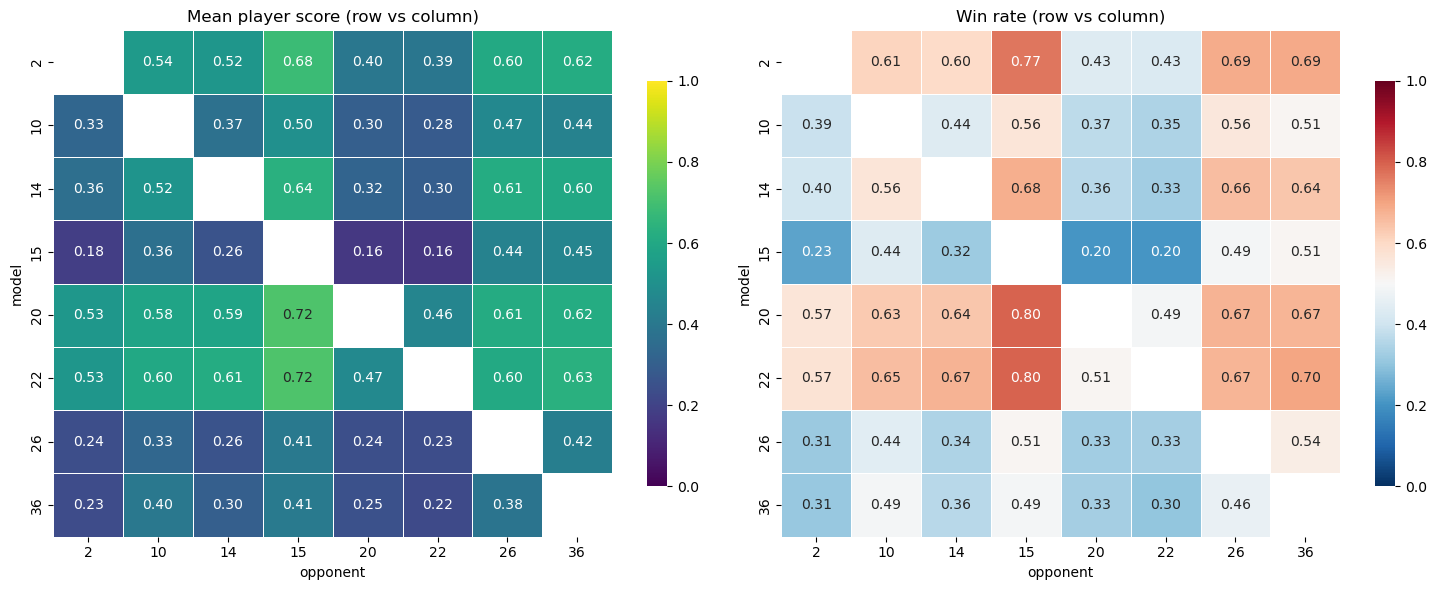

Per-matchup results (ordered A=P1 vs B=P2):


,matchup,model_A,model_B,n,p1_win_rate,mean_score_A,mean_score_B
0,260715_0002__vs__260715_0002,2,2,349,0.550,0.505,0.402
1,260715_0002__vs__260715_0010,2,10,348,0.615,0.553,0.314
2,260715_0002__vs__260715_0014,2,14,349,0.579,0.507,0.378
3,260715_0002__vs__260715_0015,2,15,349,0.756,0.676,0.189
4,260715_0002__vs__260715_0020,2,20,349,0.438,0.413,0.529
...,...,...,...,...,...,...,...
59,260715_0036__vs__260715_0015,36,15,349,0.496,0.420,0.446
60,260715_0036__vs__260715_0020,36,20,349,0.318,0.248,0.629
61,260715_0036__vs__260715_0022,36,22,349,0.292,0.215,0.639
62,260715_0036__vs__260715_0026,36,26,348,0.474,0.395,0.428


In [ ]:
# Recast to one row per (focus model, opponent) per trial, so both seat orders pool (with duplicates of every trial)
# .assign copies the dataframe, with appended new columns from the arguments
# This is done once for each framing: one with model A as the focus, one with model B as the focus
# So, every matchup is duplicated, with the duplicates representing the above framing 
# As long as this df is always indexed by focus, no need to worry about double counting
perspective = pd.concat([
    trials_df.assign(focus=trials_df.model_A, opp=trials_df.model_B,
                     f_score=trials_df.score_A, f_win=(trials_df.winner_client == 0).astype(float)),    # recast bool -> float
    trials_df.assign(focus=trials_df.model_B, opp=trials_df.model_A,
                     f_score=trials_df.score_B, f_win=(trials_df.winner_client == 1).astype(float)),
], ignore_index=True)[['matchup', 'focus', 'opp', 'f_score', 'f_win', 'sep']]
selfless = perspective[perspective.focus != perspective.opp]                  # drop self-matchups for competitive stats

# pooled head-to-head: focus's mean score and win rate vs each opponent
h2h = selfless.groupby(['focus', 'opp']).agg(score=('f_score', 'mean'), win=('f_win', 'mean')).reset_index()
# note that indexing here by models puts them in ascending order, but not in strategy type order
# (and extremity of strategy within that)
score_mat = h2h.pivot(index='focus', columns='opp', values='score').reindex(index=MODELS, columns=MODELS)
win_mat = h2h.pivot(index='focus', columns='opp', values='win').reindex(index=MODELS, columns=MODELS)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, mat, title, fmt, vmin, vmax, cmap in [
        (axes[0], score_mat, 'Mean player score (row vs column)', '.2f', 0, HIGH, 'viridis'),
        (axes[1], win_mat, 'Win rate (row vs column)', '.2f', 0, 1, 'RdBu_r')]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax,
                cbar_kws={'shrink': 0.8}, linewidths=0.5, linecolor='white')
    ax.set_title(title); ax.set_xlabel('opponent'); ax.set_ylabel('model')
plt.tight_layout(); plt.show()

print("Per-matchup results (ordered A=P1 vs B=P2):")
per_matchup.round(3)

## 3. Overall ranking

Which models are most successful, over all opponents (self-matchups excluded). The focus is **mean score per trial** (which is close to the reward over time that agents are maximising); total accumulated score and win rate are also used, plus a Bradley-Terry strength fit from the win/loss counts.

In [ ]:
# create dataframe of models indexed by model id, which is ordered by strategy type
strat1 = pd.DataFrame(STRATEGY.items()).rename(columns={0: 'model', 1: 'strategy'})
strat1.set_index('model', inplace=True)
strat1

,strategy
model,
22,central
20,central
2,central
14,intermediate
10,intermediate
36,peripheral
15,peripheral
26,peripheral


In [51]:
overall['model']

0    22
1    20
2     2
3    14
4    10
5    36
6    26
7    15
Name: model, dtype: int64

Overall ranking by mean player score per trial:
 rank  model     strategy  mean_score  total_score  win_rate  bt_strength
    1     22      central       0.596       2911.2     0.653        1.624
    2     20      central       0.586       2861.6     0.638        1.532
    3      2      central       0.537       2622.2     0.602        1.335
    4     14 intermediate       0.478       2333.8     0.519        0.982
    5     10 intermediate       0.383       1867.0     0.453        0.771
    6     36   peripheral       0.313       1525.6     0.391        0.614
    7     26   peripheral       0.303       1478.0     0.400        0.634
    8     15   peripheral       0.288       1404.6     0.342        0.507


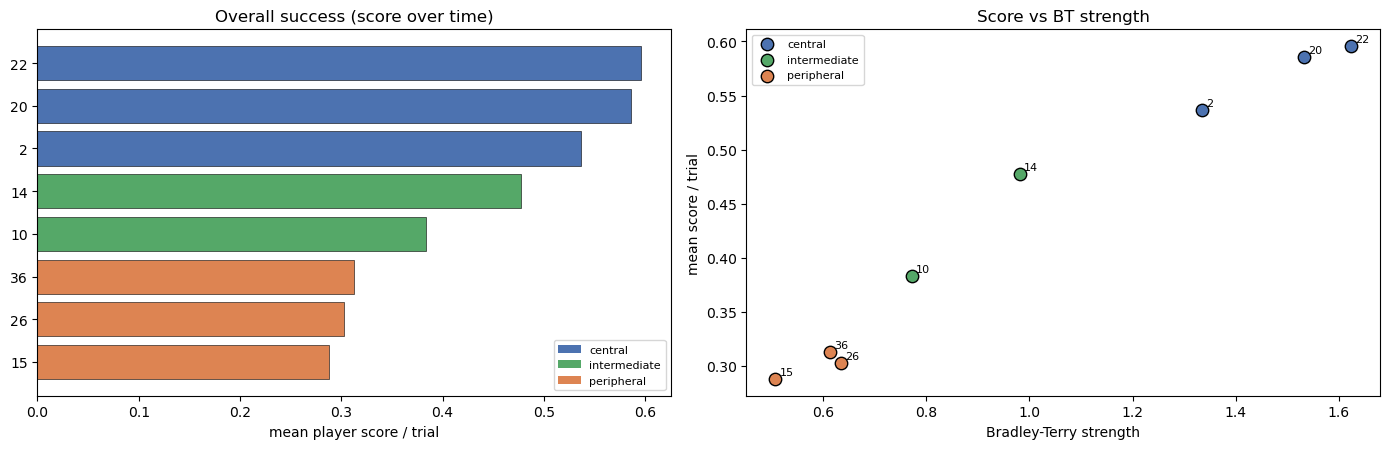

In [ ]:
# selfless and overall ['models'] are ordered by strategy type
overall = selfless.groupby('focus').agg(
    mean_score=('f_score', 'mean'),
    total_score=('f_score', 'sum'),
    win_rate=('f_win', 'mean'),
    n_trials=('f_score', 'size')).reset_index().rename(columns={'focus': 'model'})

# Bradley-Terry strengths from pooled win counts
wins_df = selfless[selfless.f_win == 1].groupby(['focus', 'opp']).size().reset_index(name='w')
wins_mat = wins_df.pivot(index='focus', columns='opp', values='w').reindex(
    index=MODELS, columns=MODELS).fillna(0).to_numpy()
# here return MODELS-length vector of bradley-terry strengths, normalised to mean 1.0
bt = fit_bradley_terry(wins_mat)
# zip MODELS and bt into a dict, and walk over 'models', replacing each with its bt strength
# Then assign this to a new 'bt_strength' column
overall['bt_strength'] = overall['model'].map(dict(zip(MODELS, bt)))
overall['strategy'] = overall['model'].map(STRATEGY)
# here the df becomes ordered by score and not strategy type, to rank models
overall = overall.sort_values('mean_score', ascending=False).reset_index(drop=True)
overall['rank'] = np.arange(1, len(overall) + 1)
print("Overall ranking by mean player score per trial:")
print(overall[['rank', 'model', 'strategy', 'mean_score', 'total_score', 'win_rate', 'bt_strength']].round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
order = overall.sort_values('mean_score')
axes[0].barh(np.arange(len(order)), order['mean_score'],
             color=[STRAT_PALETTE[s] for s in order['strategy']], edgecolor='black', linewidth=0.4)
axes[0].set_yticks(np.arange(len(order))); axes[0].set_yticklabels(order['model'])
axes[0].set_xlabel('mean player score / trial'); axes[0].set_title('Overall success (score over time)')
axes[0].legend(handles=[Patch(facecolor=STRAT_PALETTE[s], label=s) for s in STRAT_ORDER], fontsize=8)
# score vs BT strength, to see they broadly agree
for s in STRAT_ORDER:
    sub = overall[overall.strategy == s]
    axes[1].scatter(sub['bt_strength'], sub['mean_score'], s=80, color=STRAT_PALETTE[s],
                    edgecolor='black', label=s)
for _, r in overall.iterrows():
    axes[1].annotate(int(r['model']), (r['bt_strength'], r['mean_score']), fontsize=8,
                     xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel('Bradley-Terry strength'); axes[1].set_ylabel('mean score / trial')
axes[1].set_title('Score vs BT strength'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Does the pairing matter? (interaction)

If success were purely each model's general strength, every head-to-head would be predicted by the two Bradley-Terry strengths. The **residual** (actual win rate minus BT-predicted) is the part explained by the specific pairing — the interaction. Large residuals, or non-transitive loops (A beats B beats C beats A), mean the matchup itself matters, not just overall strength.

Interaction (actual - BT-predicted win rate): RMS residual 0.034, max |residual| 0.059
Non-transitive triples (rock-paper-scissors loops): 0 of 56


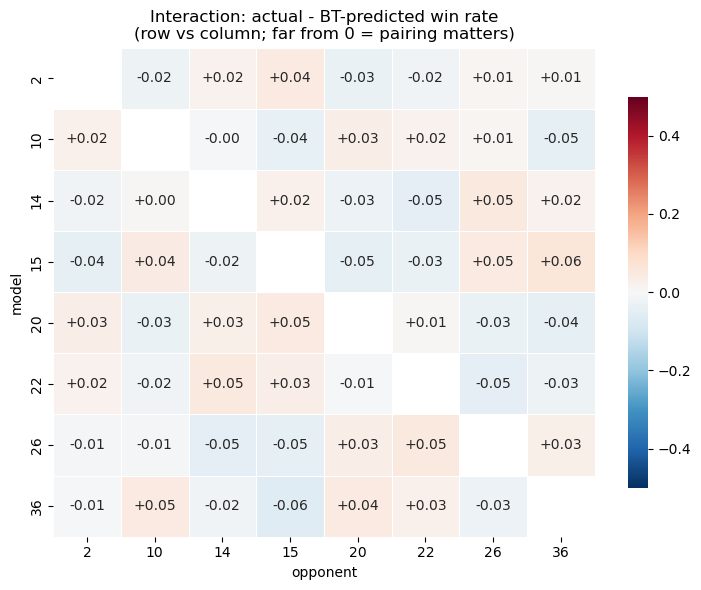

In [7]:
bt_map = dict(zip(MODELS, bt))
# BT-predicted win rate for each ordered pair, and the residual vs actual
pred = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for i in MODELS:
    for j in MODELS:
        pred.loc[i, j] = np.nan if i == j else bt_map[i] / (bt_map[i] + bt_map[j])
resid = (win_mat - pred).astype(float)

upper = [(i, j) for i, j in combinations(MODELS, 2)]
resid_vals = np.array([resid.loc[i, j] for i, j in upper])
print(f"Interaction (actual - BT-predicted win rate): RMS residual {np.sqrt(np.nanmean(resid_vals**2)):.3f}, "
      f"max |residual| {np.nanmax(np.abs(resid_vals)):.3f}")
loops = intransitive_triads(win_mat, MODELS)
print(f"Non-transitive triples (rock-paper-scissors loops): {len(loops)} of {len(list(combinations(MODELS,3)))}")
for t in loops:
    print(f"  loop: {t[0]} > {t[1]} > {t[2]} > {t[0]}  (strategies "
          f"{STRATEGY[t[0]]}/{STRATEGY[t[1]]}/{STRATEGY[t[2]]})")

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(resid, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            ax=ax, cbar_kws={'shrink': 0.8}, linewidths=0.5, linecolor='white')
ax.set_title('Interaction: actual - BT-predicted win rate\n(row vs column; far from 0 = pairing matters)')
ax.set_xlabel('opponent'); ax.set_ylabel('model')
plt.tight_layout(); plt.show()

## Reading the results

- **Validation** — trust the rest only if self-matchups sit near 0.5 and mirror gaps are small. A self-matchup far from 0.5 means the run is still unfair (as in the first, opponent-frozen run).
- **Overall ranking** — mean score per trial (representative of score over time); BT strength should track it closely. Colour shows whether a strategy band (central / intermediate / peripheral) dominates.
- **Interaction** — a small RMS residual and no non-transitive loops means success is essentially each model's general strength, and the pairing adds little. Large residuals or loops mean specific matchups (and strategy clashes) matter beyond overall strength.
- Score is winner-take-all, so a model's mean score combines how often it wins and whether it wins High vs Low; the win-rate matrix is used to separate this out

Situational analysis (per wall separation) and behavioural strategy characterisation are deliberately left to a separate notebook.

Notes for further analysis:

- in these models, and in the strategy in general, peripheral can be more stationary in the ITI (0.6-0.9 compared to 0.15-0.36) (FOR PENALTY BREAK BUILDS, so check this is indeed true)
- Wall sep analysis
- Considerations of 'energy' for turning and movement